In [ ]:
import polars as pl
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.db import PBWarehouse
from sklearn.metrics import classification_report, confusion_matrix

# Loading the dataset

In [24]:
pb = PBWarehouse()
dataset = pb.get_dataset("annotated_tweets")


# is_extremist is boolean where True means extremist
# We want to convert it to is_hateful where 0 means extremist
# and 1 means not extremist
# We want to map the booleans to the correct HateBERT class labels
correct_labels = {
    0: 1,
    1: 0,
    2: 2
    # boolean: hatebert label
}

df = pl.DataFrame(
    {
        "text": [record.text for record in dataset],
        "is_extremist": [
            correct_labels[int(record.is_extremist)] for record in dataset
        ],
    }
)
df

KeyboardInterrupt: 

In [ ]:
df["is_extremist"].value_counts()

is_extremist,count
i64,u32
1,1694
0,6


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].to_list(),
    df["is_extremist"].to_list(),
    test_size=0.2,
    random_state=42,
    stratify=df["is_extremist"].to_list()
)

# Finding the base performance

Let's use the test set to get the initial performance before finetuning.

In [ ]:
MODEL_NAME = "Hate-speech-CNERG/bert-base-uncased-hatexplain"
# HATEBERT on Hugging Face

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, attn_implementation="eager"
)

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def predict(text: str) -> int:
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    inputs.to(DEVICE)
    model.to(DEVICE)
    outputs = model(**inputs)
    logits = outputs.logits
    label = torch.argmax(torch.nn.functional.softmax(logits, dim=-1), dim=-1)
    return label.item()

In [ ]:
initial_test_preds = [predict(text) for text in X_test]

print(classification_report(y_test, initial_test_preds, digits=4))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         1
           1     1.0000    0.9735    0.9865       339
           2     0.0000    0.0000    0.0000         0

    accuracy                         0.9706       340
   macro avg     0.3333    0.3245    0.3288       340
weighted avg     0.9971    0.9706    0.9836       340



/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

In [ ]:
import numpy as np

# find all classes that are equal to '0' (extremist)
abs(np.array(y_train) - 1).sum()

np.int64(5)

Initial performance:

- missed all extreimist classes (0 f1 score for class '0')
- near perfect performance on class '1' (normal / non-extremist)

# Finetuning

In [ ]:
# Freeze all layers except the classification head
for param in model.bert.parameters():
    param.requires_grad = False


for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
EPOCHS = 16
BATCH_SIZE = 16
LR = 5e-5

# 1. Tokenize everything at once
encodings = tokenizer(
    X_train,
    return_tensors="pt"
    , padding=True,
)

labels = torch.tensor(y_train)

dataset = TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"],
    labels
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

total_steps = len(loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

def train(model, loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for step, batch in enumerate(loader):
            input_ids, attention_mask, labels = [x.to(DEVICE) for x in batch]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            if step % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Step {step}, Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f}")

train(model, loader, EPOCHS)


Epoch 1/16, Step 0, Loss: 0.3391
Epoch 1/16, Step 10, Loss: 0.3027
Epoch 1/16, Step 20, Loss: 0.1639
Epoch 1/16, Step 30, Loss: 0.1473
Epoch 1/16, Step 40, Loss: 0.0987
Epoch 1/16, Step 50, Loss: 0.2877
Epoch 1/16, Step 60, Loss: 0.0509
Epoch 1/16, Step 70, Loss: 0.0347
Epoch 1/16, Step 80, Loss: 0.0588
Epoch 1 finished. Avg Loss: 0.1501
Epoch 2/16, Step 0, Loss: 0.0361
Epoch 2/16, Step 10, Loss: 0.0156
Epoch 2/16, Step 20, Loss: 0.0144
Epoch 2/16, Step 30, Loss: 0.0160
Epoch 2/16, Step 40, Loss: 0.4243
Epoch 2/16, Step 50, Loss: 0.2438
Epoch 2/16, Step 60, Loss: 0.0097
Epoch 2/16, Step 70, Loss: 0.0098
Epoch 2/16, Step 80, Loss: 0.0060
Epoch 2 finished. Avg Loss: 0.0398
Epoch 3/16, Step 0, Loss: 0.3038
Epoch 3/16, Step 10, Loss: 0.0055
Epoch 3/16, Step 20, Loss: 0.0084
Epoch 3/16, Step 30, Loss: 0.0062
Epoch 3/16, Step 40, Loss: 0.0109
Epoch 3/16, Step 50, Loss: 0.0081
Epoch 3/16, Step 60, Loss: 0.0168
Epoch 3/16, Step 70, Loss: 0.0080
Epoch 3/16, Step 80, Loss: 0.0035
Epoch 3 finishe

# Testing

In [ ]:
preds = [predict(text) for text in X_test]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


print(classification_report(y_test, preds, digits=4))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         1
           1     0.9971    1.0000    0.9985       339

    accuracy                         0.9971       340
   macro avg     0.4985    0.5000    0.4993       340
weighted avg     0.9941    0.9971    0.9956       340



/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, preds)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

Precision-Recall AUC: 0.9985


In [ ]:
predict("I hate asd")

1

# Augmenting the dataset with our own classified dataset

In [ ]:
big_dataset = pb.get_dataset("dataset")

In [ ]:
base_df = pl.DataFrame(
    {
        "text": [record.text for record in big_dataset],
        "is_extremist": [
            int(record.is_hateful) for record in big_dataset
        ],
    }
)
base_df

text,is_extremist
str,i64
"""@TRCdocumentary @Blklivesmatte…",1
"""@terrycrews @jonathanwsabin Th…",1
"""Join Bernie and Sunrise leader…",1
"""@prageru It's not the women's …",1
"""A #BlackLivesMatter protest in…",1
…,…
"""I curated a list of black-owne…",1
"""Defund. Disarm. Dismantle. #De…",1
"""Bill Nye with the mic drop. #S…",1


In [ ]:
base_df["is_extremist"].value_counts()

is_extremist,count
i64,u32
1,35548
2,765
0,51


In [ ]:
augmented_dataset = pl.concat([df, base_df]).unique(subset=["text"], keep="last")
augmented_dataset

text,is_extremist
str,i64
"""This is right out of some movi…",1
"""Make no mistake; when they say…",1
"""“Don’t be mad because you don’…",1
"""@EJinAction @DeeTwoCents There…",2
"""Leader of #UK #BlackLivesMatte…",1
…,…
"""@ellymelly Yes - where the tol…",1
"""@BriansNewHeart Brian. I agree…",1
"""Watch for an announcement of a…",1


In [ ]:
from src.config import PROCESSED_DATA_DIR

augmented_dataset.write_csv(PROCESSED_DATA_DIR / "augmented_dataset.csv")

In [26]:
from src.config import PROCESSED_DATA_DIR
augmented_dataset = pl.read_csv(PROCESSED_DATA_DIR / "augmented_dataset.csv")

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    augmented_dataset["text"].to_list(),
    augmented_dataset["is_extremist"].to_list(),
    test_size=0.2,
    random_state=42,
    stratify=augmented_dataset["is_extremist"].to_list()
)

len(X_train), len(X_test)

(28809, 7203)

In [28]:
MODEL_NAME = "Hate-speech-CNERG/bert-base-uncased-hatexplain"
# HATEBERT on Hugging Face

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, attn_implementation="eager"
)

In [29]:
# Freeze all layers except the classification head
for param in model.bert.parameters():
    param.requires_grad = False


for param in model.classifier.parameters():
    param.requires_grad = True

In [30]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def predict(text: str, model) -> int:
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    inputs.to(DEVICE)
    model.to(DEVICE)
    outputs = model(**inputs)
    logits = outputs.logits
    label = torch.argmax(torch.nn.functional.softmax(logits, dim=-1), dim=-1)
    return label.item()


In [31]:
preds = [predict(text, model) for text in X_test]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


print(classification_report(y_test, preds, digits=4))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


              precision    recall  f1-score   support

           0     0.9167    1.0000    0.9565        11
           1     1.0000    1.0000    1.0000      7039
           2     1.0000    0.9935    0.9967       153

    accuracy                         0.9999      7203
   macro avg     0.9722    0.9978    0.9844      7203
weighted avg     0.9999    0.9999    0.9999      7203



In [ ]:
EPOCHS = 64
BATCH_SIZE = 16
LR = 5e-5

# 1. Tokenize everything at once
encodings = tokenizer(
    X_train,
    return_tensors="pt"
    , padding=True,
)

labels = torch.tensor(y_train)

dataset = TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"],
    labels
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

total_steps = len(loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

def train(model, loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for step, batch in enumerate(loader):
            input_ids, attention_mask, labels = [x.to(DEVICE) for x in batch]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            if step % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Step {step}, Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f}")

train(model, loader, EPOCHS)


Epoch 1/64, Step 0, Loss: 0.2840
Epoch 1/64, Step 10, Loss: 0.0000
Epoch 1/64, Step 20, Loss: 0.0000
Epoch 1/64, Step 30, Loss: 0.0000
Epoch 1/64, Step 40, Loss: 0.0002
Epoch 1/64, Step 50, Loss: 0.0000
Epoch 1/64, Step 60, Loss: 0.0000
Epoch 1/64, Step 70, Loss: 0.0000
Epoch 1/64, Step 80, Loss: 0.0000
Epoch 1/64, Step 90, Loss: 0.0000
Epoch 1/64, Step 100, Loss: 0.0432
Epoch 1/64, Step 110, Loss: 0.0000
Epoch 1/64, Step 120, Loss: 1.6756
Epoch 1/64, Step 130, Loss: 3.1670
Epoch 1/64, Step 140, Loss: 0.0000
Epoch 1/64, Step 150, Loss: 0.0000
Epoch 1/64, Step 160, Loss: 0.0000
Epoch 1/64, Step 170, Loss: 0.0000
Epoch 1/64, Step 180, Loss: 0.0000
Epoch 1/64, Step 190, Loss: 1.5983
Epoch 1/64, Step 200, Loss: 0.0000
Epoch 1/64, Step 210, Loss: 2.8244
Epoch 1/64, Step 220, Loss: 0.0000
Epoch 1/64, Step 230, Loss: 0.0000
Epoch 1/64, Step 240, Loss: 0.0000
Epoch 1/64, Step 250, Loss: 0.0000
Epoch 1/64, Step 260, Loss: 0.4994
Epoch 1/64, Step 270, Loss: 0.0000
Epoch 1/64, Step 280, Loss: 0.0

In [34]:
preds = [predict(text, model) for text in X_test]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


print(classification_report(y_test, preds, digits=4))

              precision    recall  f1-score   support

           0     0.5385    0.6364    0.5833        11
           1     0.9933    0.9964    0.9949      7039
           2     0.7907    0.6667    0.7234       153

    accuracy                         0.9889      7203
   macro avg     0.7742    0.7665    0.7672      7203
weighted avg     0.9883    0.9889    0.9885      7203



In [ ]:
# learning rate 0.1
history = {
    # epochs
    64: {
        # class
        0: {
            "precision": 0.5385,
            "recall": 0.6364,
            "f1-score": 0.5833,
        },
        1: {
            "precision": 0.9933,
            "recall": 0.9964,
            "f1-score": 0.9949,
        },
        2: {
            "precision": 0.7907,
            "recall": 0.6667,
            "f1-score": 0.7234,
        },
    }
}

In [ ]:
# learning rate 5e-5
history = {
    # epochs
    3: {
        # class
        0: {
            # metrics
            "precision": 1.0000,
            "recall": 0.1818,
            "f1-score": 0.3077,
        },
        1: {
            "precision": 0.9896,
            "recall": 0.9983,
            "f1-score": 0.9939,
        },
        2: {
            "precision": 0.8100,
            "recall": 0.5294,
            "f1-score": 0.6403,
        },
    },
    6: {
        0: {
            "precision": 0.6000,
            "recall": 0.2727,
            "f1-score": 0.3750,
        },
        1: {
            "precision": 0.9906,
            "recall": 0.9982,
            "f1-score": 0.9943,
        },
        2: {
            "precision": 0.8476,
            "recall": 0.5817,
            "f1-score": 0.6899,
        },
    },
    12: {
        0: {
            "precision": 1.0000,
            "recall": 0.3636,
            "f1-score": 0.5333,
        },
        1: {
            "precision": 0.9919,
            "recall": 0.9970,
            "f1-score": 0.9945,
        },
        2: {
            "precision": 0.8065,
            "recall": 0.6536,
            "f1-score": 0.7220,
        },
    },
    16: {
        0: {
            "precision": 0.8000,
            "recall": 0.3636,
            "f1-score": 0.5000,
        },
        1: {
            "precision": 0.9934,
            "recall": 0.9980,
           "f1-score": 0.9957,
        },
        2: {
            "precision": 0.8571,
            "recall": 0.7059,
            "f1-score": 0.7742,
        },
    },
    32: {
        0: {
            "precision": 0.8333,
            "recall": 0.4545,
            "f1-score": 0.5882,
        },
        1: {
            "precision": 0.9939,
            "recall": 0.9969,
           "f1-score": 0.9954,
        },
        2: {
            "precision": 0.8175,
            "recall": 0.7320,
            "f1-score": 0.7724,
        },
    }

}

Text(0, 0.5, 'F1-Score')

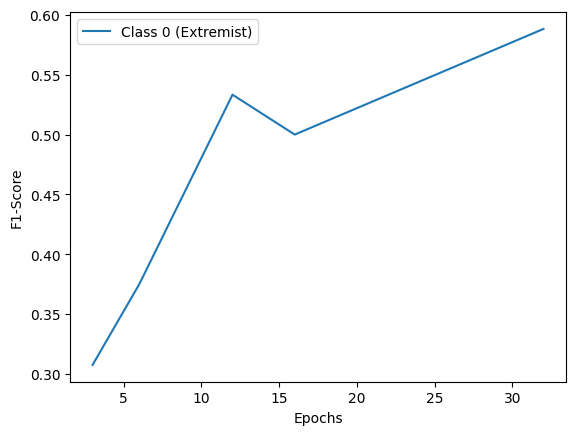

In [ ]:
sns.lineplot(
    x=list(history.keys()),
    y=[history[epoch][0]["f1-score"] for epoch in history.keys()],
    label="Class 0 (Extremist)",
)
plt.xlabel("Epochs")
plt.ylabel("F1-Score")

In [ ]:
nums = [1, 2, 3, 4, 5]


sorted(reversed(nums)) == sorted(nums)

True